# 03 Residuals

This notebook extracts and analyzes VAR residuals from the fitted models.

The goal is to examine whether the residuals reveal innovation misspecification across the simulated DGPs.

This notebook motivates the innovation-modeling stage by showing when Gaussian residual assumptions are reasonable and when they fail.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.append(str(ROOT))

import numpy as np
import pandas as pd

from src.utils.seeds import set_seed
from src.utils.device import get_device

from src.experiments.config import ExperimentConfig
from src.experiments.paths import result_dirs
from src.experiments.artifacts import (
    load_array_npz,
    save_array_npz,
    save_table,
    save_json,
    save_current_figure,
)

from src.api.modeling import extract_residuals

set_seed(123)

config = ExperimentConfig()
dgp_names = config.dgp_names

lags = config.lags
n_train = config.n_train
n_test = 100

rnn_context_length = 40
rnn_prediction_length = 40
rnn_hidden_dim = 64
rnn_num_layers = 1
rnn_dropout = 0.0
rnn_batch_size = 32
rnn_epochs = 100
rnn_lr = 1e-3
rnn_device = get_device()

dirs = result_dirs(
    "03_residuals",
    test=False,
)

simulated_dir = ROOT / "data" / "simulated"

datasets = {}

for name in dgp_names:
    path = simulated_dir / f"{name}_var_dgp.npz"
    data = load_array_npz(path)

    y = data["y"]

    datasets[name] = {
        "y": y,
        "y_train": y[:n_train],
        "y_test": y[n_train:n_train + n_test],
        "innovations": data["innovations"],
        "A": data["A"],
        "Sigma": data["Sigma"],
    }

    print(
        name,
        datasets[name]["y_train"].shape,
        datasets[name]["y_test"].shape,
    )

gaussian (300, 3) (100, 3)
student_t (300, 3) (100, 3)
mixture (300, 3) (100, 3)
heteroskedastic (300, 3) (100, 3)


In [2]:
from src.api.residuals import extract_forecast_residuals

residual_store = extract_forecast_residuals(
    datasets=datasets,
    lags=lags,
    rnn_context_length=rnn_context_length,
    rnn_prediction_length=rnn_prediction_length,
    rnn_hidden_dim=rnn_hidden_dim,
    rnn_num_layers=rnn_num_layers,
    rnn_dropout=rnn_dropout,
    rnn_batch_size=rnn_batch_size,
    rnn_epochs=rnn_epochs,
    rnn_lr=rnn_lr,
    rnn_device=rnn_device,
)

var_residual_store = residual_store["VAR"]
rnn_residual_store = residual_store["RNN"]

gaussian VAR: (299, 3) RNN: (260, 3)
student_t VAR: (299, 3) RNN: (260, 3)
mixture VAR: (299, 3) RNN: (260, 3)
heteroskedastic VAR: (299, 3) RNN: (260, 3)


In [3]:
for name in dgp_names:

    save_array_npz(
        dirs["residuals"] / f"{name}_var_residuals.npz",
        residuals=var_residual_store[name],
    )

    save_array_npz(
        dirs["residuals"] / f"{name}_rnn_residuals.npz",
        residuals=rnn_residual_store[name],
    )

print(
    "Saved residual files:",
    dirs["residuals"]
)

Saved residual files: /Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/results/residuals/03_residuals


In [4]:
from src.api.residuals import residual_diagnostics_table

residual_diagnostics_df = residual_diagnostics_table(
    var_residual_store=var_residual_store,
    rnn_residual_store=rnn_residual_store,
)

save_table(
    residual_diagnostics_df,
    dirs["tables"] / "residual_diagnostics.csv",
)

residual_diagnostics_df

,dgp,forecast_model,series,n_residuals,mean,std,skewness,kurtosis,excess_kurtosis,jb_stat,jb_pvalue
0,gaussian,VAR,1,299,-1.930823e-17,1.018841,-0.213540,3.365426,0.365426,3.684234,1.584815e-01
1,gaussian,VAR,2,299,-1.708035e-17,0.979803,0.245287,3.304344,0.304344,3.939902,1.394637e-01
2,gaussian,VAR,3,299,9.654113e-18,1.032848,0.041653,2.989496,-0.010504,0.097052,9.526328e-01
3,student_t,VAR,1,299,1.930823e-17,1.395511,0.329639,7.835382,4.835382,284.667627,1.531829e-62
4,student_t,VAR,2,299,1.299592e-17,1.410934,0.295128,7.625325,4.625325,259.765879,3.913417e-57
5,student_t,VAR,3,299,2.246438e-16,1.350534,-1.269022,9.825909,6.825909,637.417498,3.859659e-139
6,mixture,VAR,1,299,-4.567138e-17,1.396293,0.127442,5.084904,2.084904,52.151057,4.737419e-12
7,mixture,VAR,2,299,-7.574766e-17,1.368537,-0.101312,6.905191,3.905191,182.321577,2.566685e-40
8,mixture,VAR,3,299,-1.203051e-16,1.483647,-0.195361,7.274322,4.274322,219.891066,1.783453e-48
9,heteroskedastic,VAR,1,299,-1.342293e-16,1.899822,-0.525117,5.594649,2.594649,93.440504,5.124509e-21


In [5]:
from src.api.residuals import residual_diagnostics_summary

summary_df = residual_diagnostics_summary(
    residual_diagnostics_df,
)

save_table(
    summary_df,
    dirs["tables"] / "residual_diagnostics_summary.csv",
)

summary_df

,dgp,forecast_model,mean,std,skewness,kurtosis,excess_kurtosis,jb_pvalue
0,gaussian,RNN,6.269799e-02,0.965703,0.003433,3.322708,0.322708,2.299751e-01
1,gaussian,VAR,-8.911489e-18,1.010497,0.024466,3.219755,0.219755,4.168593e-01
2,heteroskedastic,RNN,1.853658e-02,1.852005,-0.314054,5.757487,2.757487,1.164478e-15
3,heteroskedastic,VAR,-5.117918e-17,1.806943,-0.091313,5.683345,2.683345,6.997397e-20
4,mixture,RNN,7.534613e-03,1.406355,-0.020831,6.467531,3.467531,2.072638e-07
5,mixture,VAR,-8.057471e-17,1.416159,-0.056410,6.421472,3.421472,1.579140e-12
6,student_t,RNN,-3.363383e-02,1.288047,-0.406328,6.559198,3.559198,8.236475e-18
7,student_t,VAR,8.564931e-17,1.385660,-0.214752,8.428872,5.428872,1.304477e-57


Saved: var_rnn_residual_histograms.png


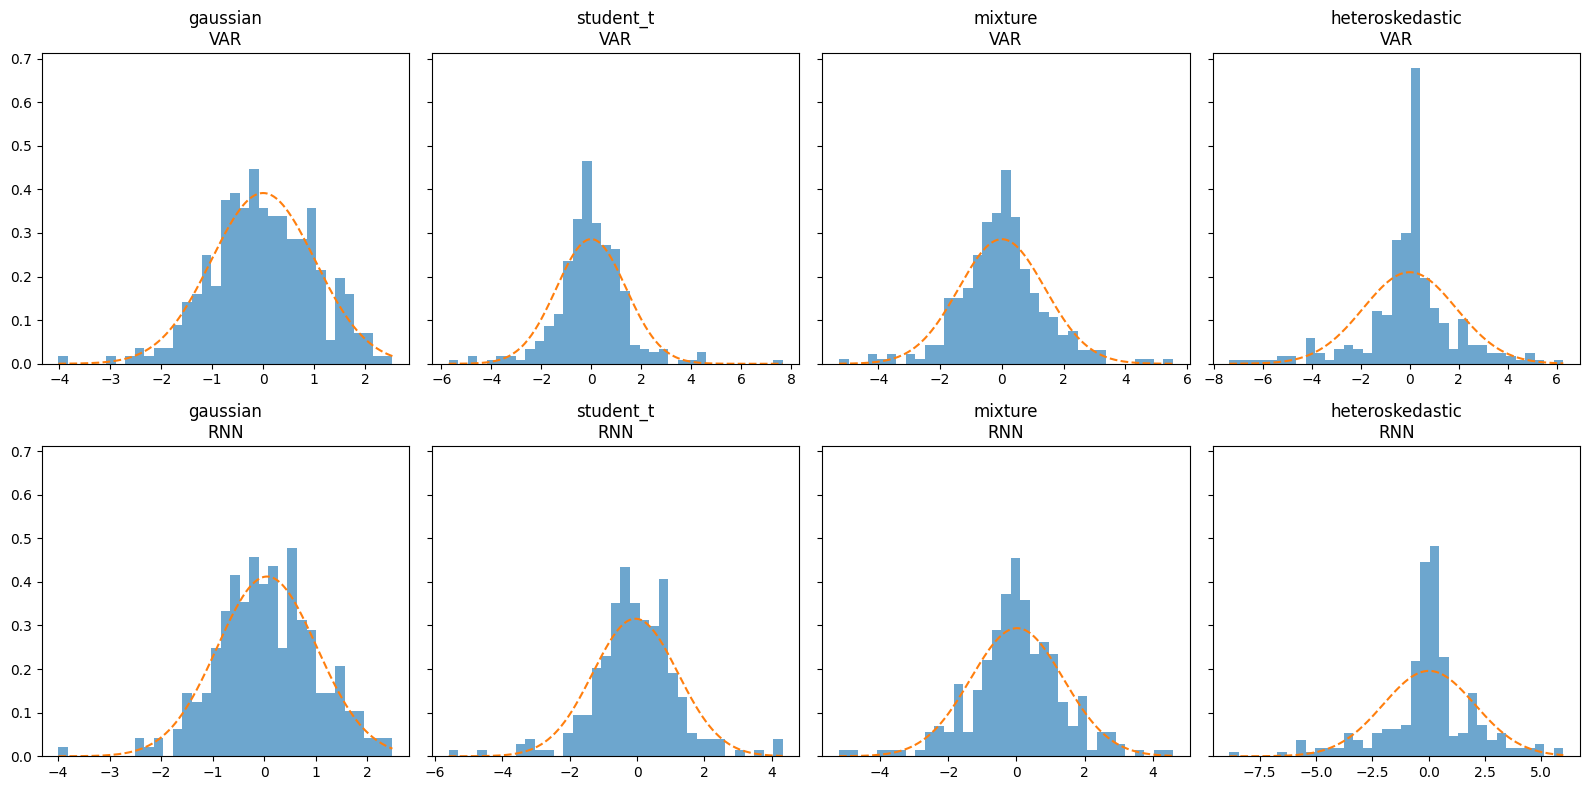

In [6]:
from src.plots.residuals import plot_residual_histograms

plot_residual_histograms(
    var_residual_store=var_residual_store,
    rnn_residual_store=rnn_residual_store,
    dgp_names=dgp_names,
    variable=0,
)

save_current_figure(
    dirs["figures"]
    / "var_rnn_residual_histograms.png"
)

print(
    "Saved: var_rnn_residual_histograms.png"
)

Saved: var_rnn_residual_qqplots.png


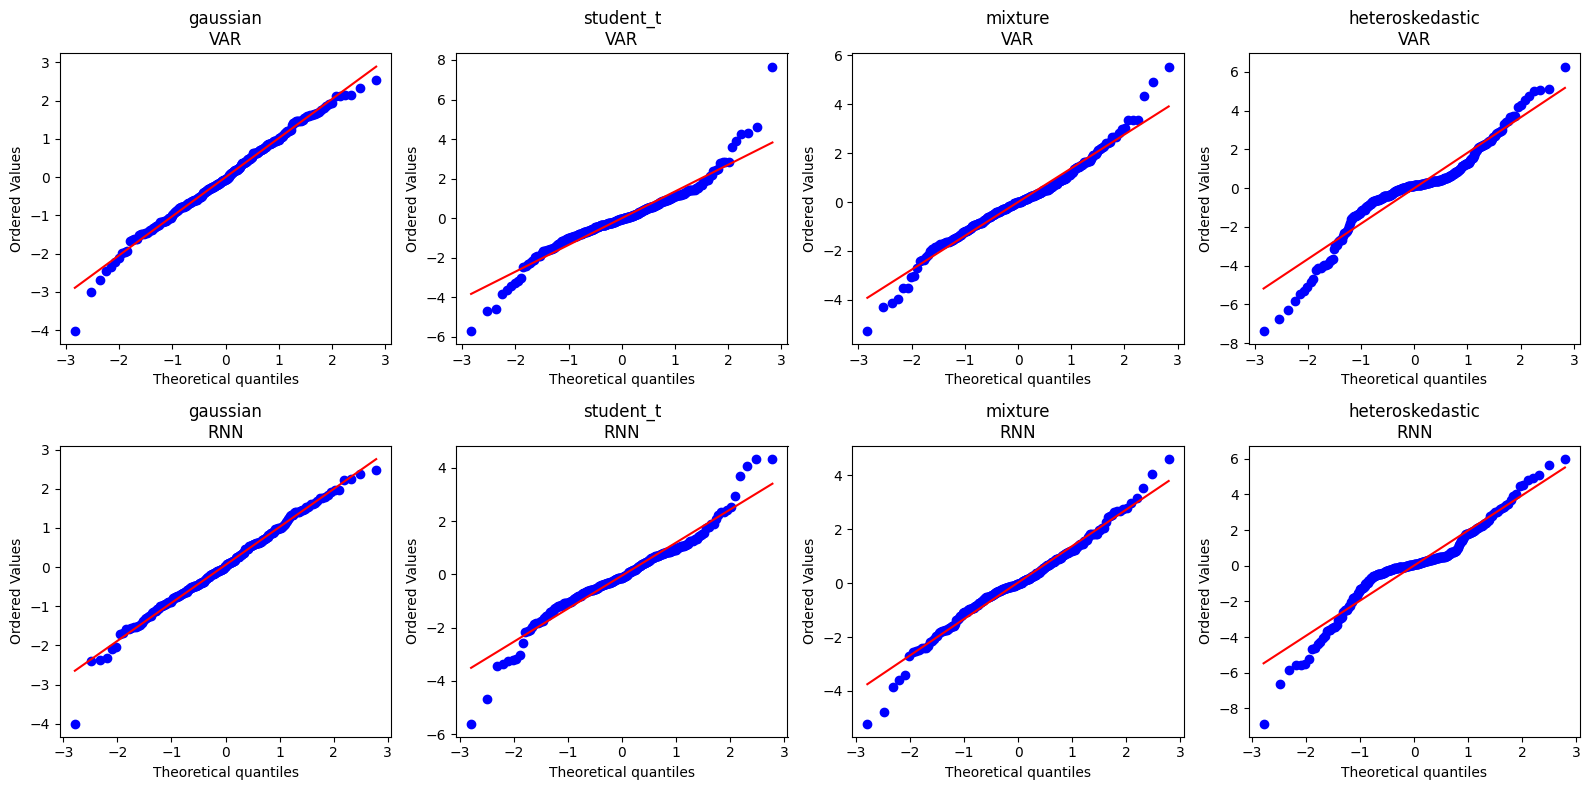

In [7]:
from src.plots.residuals import plot_residual_qqplots

plot_residual_qqplots(
    var_residual_store=var_residual_store,
    rnn_residual_store=rnn_residual_store,
    dgp_names=dgp_names,
    variable=0,
)

save_current_figure(
    dirs["figures"]
    / "var_rnn_residual_qqplots.png"
)

print(
    "Saved: var_rnn_residual_qqplots.png"
)

Saved: var_rnn_residual_acf.png


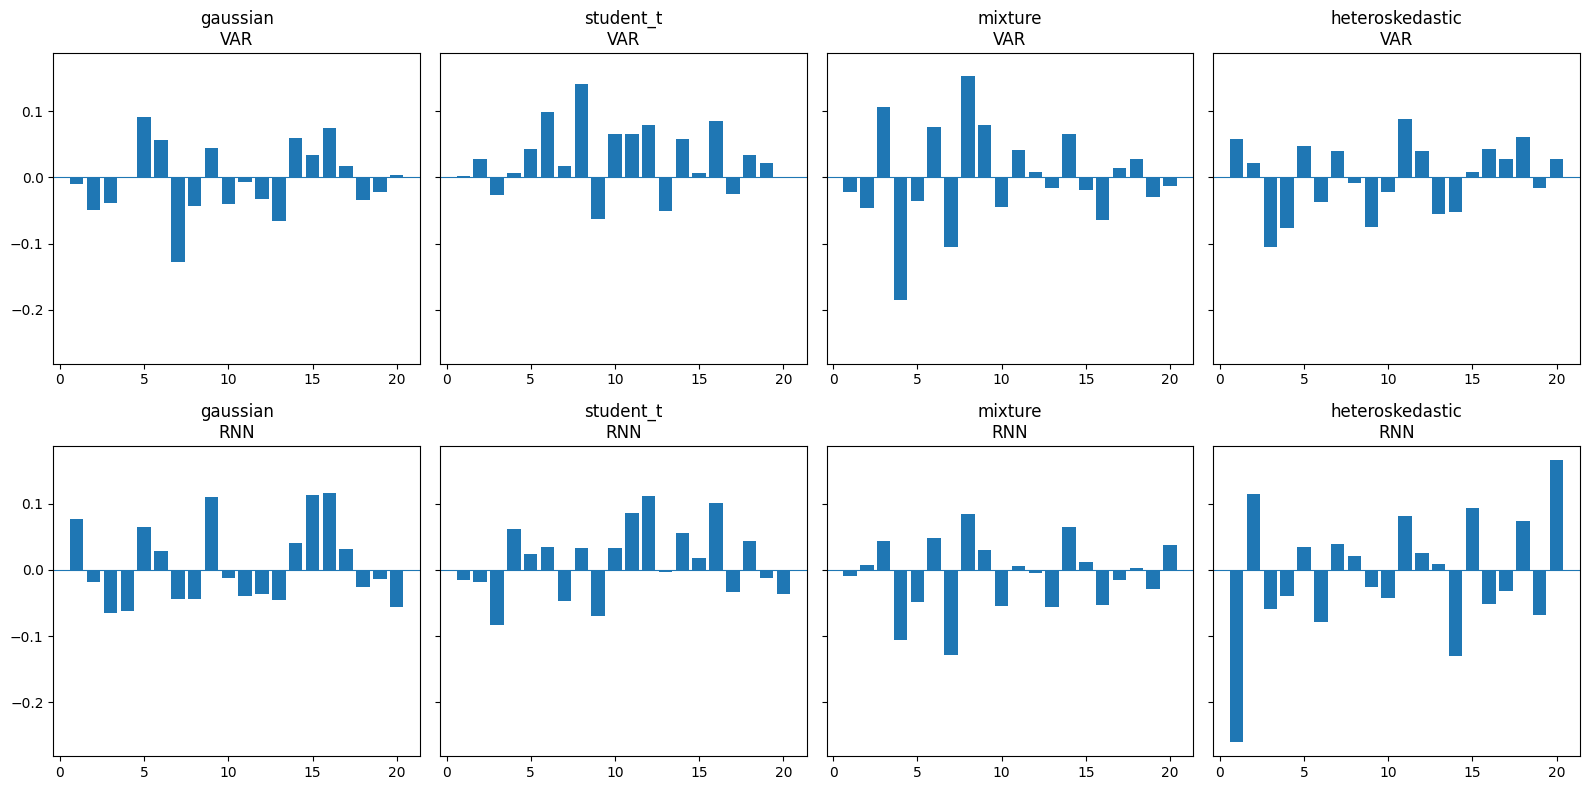

In [8]:
from src.plots.residuals import plot_residual_acf

plot_residual_acf(
    var_residual_store=var_residual_store,
    rnn_residual_store=rnn_residual_store,
    dgp_names=dgp_names,
    variable=0,
    max_lag=20,
)

save_current_figure(
    dirs["figures"]
    / "var_rnn_residual_acf.png"
)

print(
    "Saved: var_rnn_residual_acf.png"
)

In [9]:
from src.api.residuals import residual_acf_summary

acf_df = residual_acf_summary(
    var_residual_store=var_residual_store,
    rnn_residual_store=rnn_residual_store,
)

save_table(
    acf_df,
    dirs["tables"] / "residual_acf_summary.csv",
)

acf_df

,dgp,forecast_model,acf_lag1,acf_lag5
0,gaussian,VAR,-0.009457,0.091311
1,student_t,VAR,0.002325,0.043607
2,mixture,VAR,-0.022242,-0.034826
3,heteroskedastic,VAR,0.057354,0.047629
4,gaussian,RNN,0.076433,0.065549
5,student_t,RNN,-0.014446,0.023406
6,mixture,RNN,-0.009389,-0.048566
7,heteroskedastic,RNN,-0.260047,0.034019


Saved: var_rnn_rolling_residual_std.png


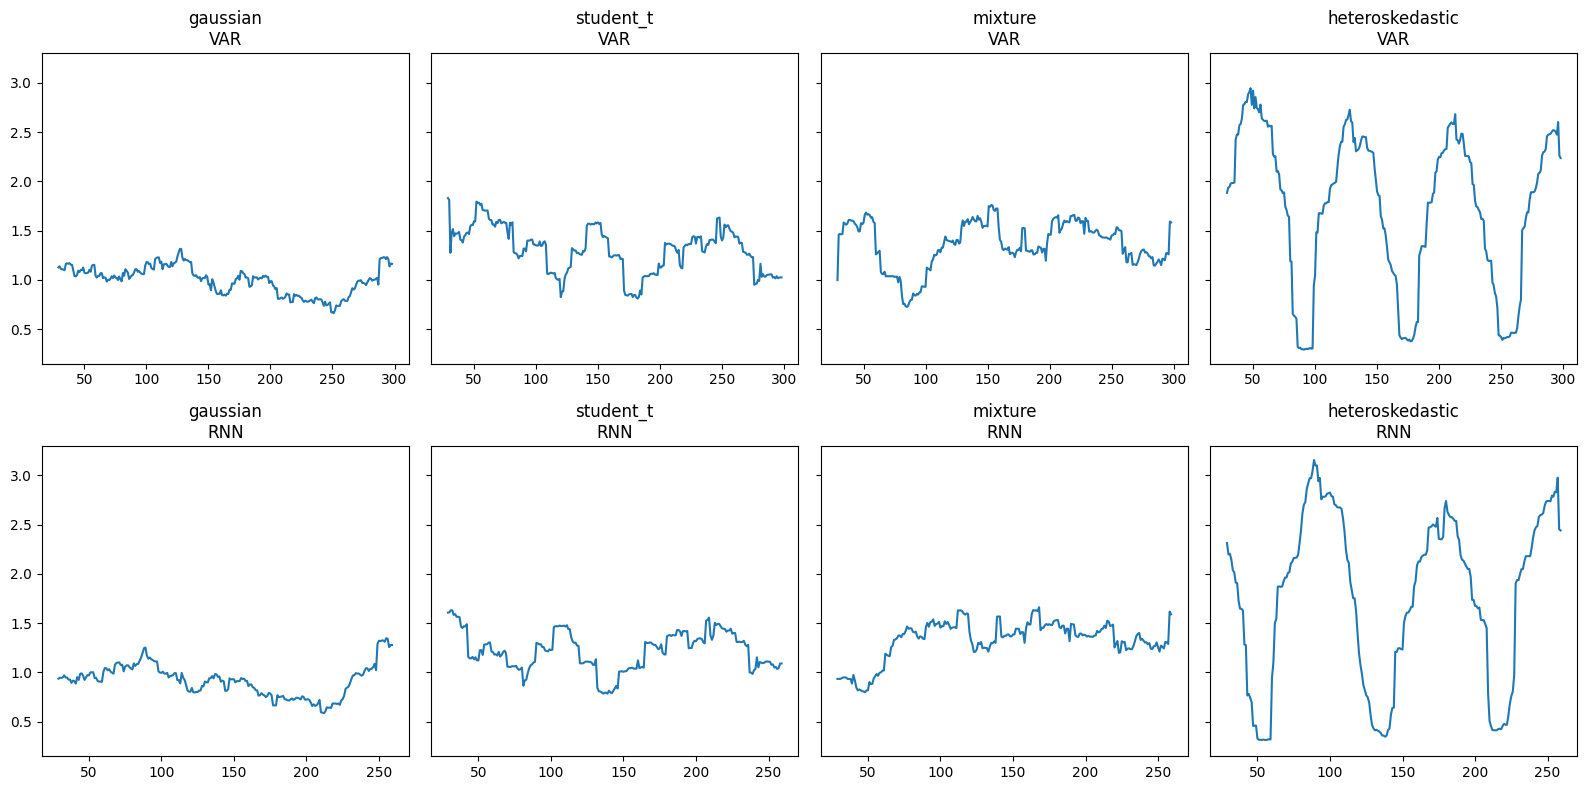

In [10]:
from src.plots.residuals import plot_rolling_residual_std

window = 30

plot_rolling_residual_std(
    var_residual_store=var_residual_store,
    rnn_residual_store=rnn_residual_store,
    dgp_names=dgp_names,
    variable=0,
    window=window,
)

save_current_figure(
    dirs["figures"]
    / "var_rnn_rolling_residual_std.png"
)

print(
    "Saved: var_rnn_rolling_residual_std.png"
)

In [11]:
from src.api.residuals import rolling_variance_summary

variance_df = rolling_variance_summary(
    var_residual_store=var_residual_store,
    rnn_residual_store=rnn_residual_store,
    window=window,
)

save_table(
    variance_df,
    dirs["tables"]
    / "rolling_variance_summary.csv",
)

variance_df

,dgp,forecast_model,mean_rolling_std,std_rolling_std,cv_rolling_std
0,gaussian,VAR,0.999461,0.143683,0.143760
1,student_t,VAR,1.307206,0.232358,0.177752
2,mixture,VAR,1.362884,0.236973,0.173876
3,heteroskedastic,VAR,1.736533,0.790969,0.455487
4,gaussian,RNN,0.917732,0.163919,0.178613
5,student_t,RNN,1.218888,0.196995,0.161619
6,mixture,RNN,1.329318,0.201703,0.151734
7,heteroskedastic,RNN,1.762279,0.855015,0.485176


In [12]:
save_json(
    {
        "notebook": "03_residuals",
        "forecast_models": [
            "VAR",
            "RNN",
        ],
        "dgp_names": dgp_names,
        "n_train": n_train,
        "lags": lags,
        "rnn_context_length": rnn_context_length,
        "rnn_prediction_length": rnn_prediction_length,
        "residual_diagnostics_saved": True,
        "histograms_saved": True,
        "qqplots_saved": True,
        "acf_plots_saved": True,
        "rolling_variance_plots_saved": True,
    },
    dirs["logs"] / "residual_metadata.json",
)

print(
    "03_residuals completed."
)

03_residuals completed.
